# Optimización del Modelo Seleccionado: Regresión Logística

En este notebook se optimiza el modelo ganador identificado en el análisis comparativo: **Regresión Logística (sin balance)**.

El objetivo es mejorar su rendimiento mediante búsqueda de hiperparámetros, validación cruzada y evaluación cuantitativa y cualitativa, siguiendo las recomendaciones del Proyecto Final:

- Optimización precisa (GridSearch / RandomSearch)
- Evaluación de criterios cuantitativos (F1-score, AUC)
- Evaluación de criterios inadecuados (tiempo, interpretabilidad, simplicidad)
- Documentación de trade-offs


# Carga de datos y procesamiento

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# 1) Cargar dataset limpio (usa el que elegiste en los otros notebooks)
df = pd.read_parquet("survey_ai_usage_clean_filtered.parquet")

# 2) Variables predictoras y objetivo
X = df.drop(columns=["AI_Usage"])
y = df["AI_Usage"]

# 3) Columnas categóricas y numéricas
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_cols, num_cols


(['DevType',
  'LanguageHaveWorkedWith',
  'Country',
  'RemoteWork',
  'Industry',
  'OrgSize',
  'EdLevel'],
 ['WorkExp', 'NumLanguages'])

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

base_clf = LogisticRegression(
    max_iter=1000,
    solver="liblinear",  # buen punto de partida para L1/L2
    n_jobs=-1
)

base_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", base_clf)
])


# Baseline antes de optimizar (todas las métricas)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

base_pipeline.fit(X_train, y_train)
y_pred_base = base_pipeline.predict(X_test)
y_proba_base = base_pipeline.predict_proba(X_test)[:, 1]

def compute_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_1": precision_score(y_true, y_pred, pos_label=1),
        "recall_1": recall_score(y_true, y_pred, pos_label=1),
        "f1_1": f1_score(y_true, y_pred, pos_label=1),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

baseline_metrics = compute_metrics(y_test, y_pred_base, y_proba_base)
baseline_metrics


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


{'accuracy': 0.7910176924240133,
 'precision_1': 0.8002502737368997,
 'recall_1': 0.9798889101704654,
 'f1_1': 0.8810056827966247,
 'roc_auc': np.float64(0.6733014962782926)}

In [10]:
print(classification_report(y_test, y_pred_base))


              precision    recall  f1-score   support

           0       0.52      0.08      0.14      1392
           1       0.80      0.98      0.88      5221

    accuracy                           0.79      6613
   macro avg       0.66      0.53      0.51      6613
weighted avg       0.74      0.79      0.73      6613



# Grid Search (versión light para Colab)

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__solver": ["liblinear"],  # liblinear soporta l1 y l2
}

grid = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="f1",       # criterio preciso principal
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_


Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


({'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'},
 np.float64(0.8826379994426758))

# Randomized Search opcional (más amplio, pero controlado)

In [12]:
from scipy.stats import loguniform

param_dist = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": loguniform(1e-3, 1e2),  # rango continuo
    "clf__solver": ["liblinear"],
}

random_search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_dist,
    n_iter=20,             # controla el tiempo
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

random_search.best_params_, random_search.best_score_


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


({'clf__C': np.float64(0.04661686413912769),
  'clf__penalty': 'l2',
  'clf__solver': 'liblinear'},
 np.float64(0.8827267223089651))

# Evaluar el modelo optimizado (todas las métricas)

In [13]:
best_logreg = grid.best_estimator_

y_pred_opt = best_logreg.predict(X_test)
y_proba_opt = best_logreg.predict_proba(X_test)[:, 1]

opt_metrics = compute_metrics(y_test, y_pred_opt, y_proba_opt)
opt_metrics


{'accuracy': 0.789354302132164,
 'precision_1': 0.7908814589665654,
 'recall_1': 0.996743918789504,
 'f1_1': 0.8819591560037285,
 'roc_auc': np.float64(0.6642707693510073)}

In [14]:
# Comparación en tabla
results_compare = pd.DataFrame([baseline_metrics, opt_metrics],
                               index=["Baseline", "LogReg optimizada"]).T
results_compare


,Baseline,LogReg optimizada
accuracy,0.791018,0.789354
precision_1,0.800250,0.790881
recall_1,0.979889,0.996744
f1_1,0.881006,0.881959
roc_auc,0.673301,0.664271


In [15]:
# guarda grafica
results_compare.to_csv("logreg_optimization_metrics.csv", index=True)


# Matriz de confusión antes y después

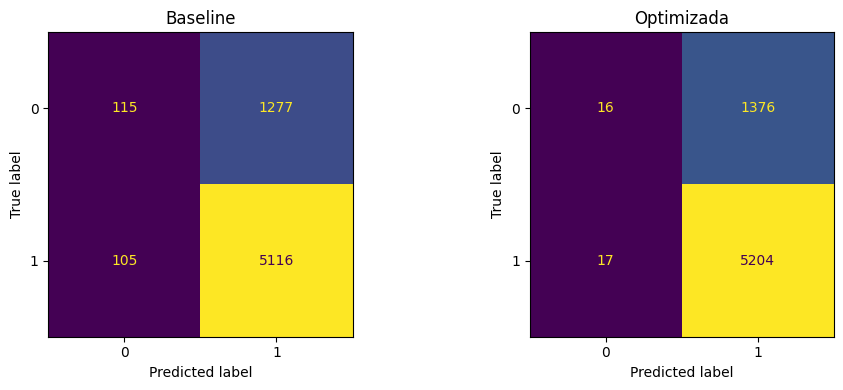

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_base = confusion_matrix(y_test, y_pred_base)
cm_opt = confusion_matrix(y_test, y_pred_opt)

ConfusionMatrixDisplay(cm_base).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Baseline")

ConfusionMatrixDisplay(cm_opt).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Optimizada")

plt.tight_layout()
plt.show()


In [17]:
fig.savefig("confusion_matrices_logreg_optimization.png",
            bbox_inches="tight", dpi=150)
